In [11]:
# Cell 1 - Import libraries and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import xgboost as xgb
import lightgbm as lgb
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

BASE = r'C:\Users\rihan\Documents\CropLens'
PROCESSED = f'{BASE}\\data\\processed'
MODELS = f'{BASE}\\models'

# Load master dataset
master_df = pd.read_csv(f'{PROCESSED}\\master_dataset.csv')

print("Shape:", master_df.shape)
print("Columns:", master_df.columns.tolist())
print("\nRisk distribution:")
print(master_df['risk_level'].value_counts())
print("\n✅ Data loaded successfully")

Shape: (8288, 31)
Columns: ['state', 'district', 'crop', 'year', 'season', 'area_hectares', 'production_tonnes', 'yield_kg_per_hectare', 'subdivision', 'year_num', 'soil_type', 'compatibility_score', 'annual_rainfall', 'monsoon_rainfall', 'rainfall_deviation_pct', 'rain_june', 'rain_july', 'rain_august', 'rain_september', 'normal_annual_rainfall', 'msp_per_quintal', 'msp_growth_rate', 'yield_lag_1', 'yield_lag_2', 'yield_lag_3', 'yield_3yr_avg', 'yield_trend', 'yield_volatility', 'drought_streak', 'district_crop_avg_yield', 'risk_level']

Risk distribution:
risk_level
High Risk      3275
Low Risk       2829
Medium Risk    2184
Name: count, dtype: int64

✅ Data loaded successfully


In [12]:
# Cell 2 - Prepare features for ML
# Select feature columns for ML
feature_cols = [
    # Rainfall features
    'annual_rainfall', 'monsoon_rainfall', 'rainfall_deviation_pct',
    'rain_june', 'rain_july', 'rain_august', 'rain_september',
    'normal_annual_rainfall', 'drought_streak',
    
    # Yield history features
    'yield_lag_1', 'yield_lag_2', 'yield_lag_3',
    'yield_3yr_avg', 'yield_trend', 'yield_volatility',
    
    # Soil features
    'compatibility_score',
    
    # Economic features
    'msp_per_quintal', 'msp_growth_rate',
    
    # Area feature
    'area_hectares',
]

# Encode categorical columns
le_crop = LabelEncoder()
le_soil = LabelEncoder()
le_season = LabelEncoder()
le_district = LabelEncoder()

master_df['crop_encoded'] = le_crop.fit_transform(master_df['crop'])
master_df['soil_encoded'] = le_soil.fit_transform(master_df['soil_type'])
master_df['season_encoded'] = le_season.fit_transform(master_df['season'])
master_df['district_encoded'] = le_district.fit_transform(master_df['district'])

# Add encoded columns to features
feature_cols += ['crop_encoded', 'soil_encoded', 
                 'season_encoded', 'district_encoded']

# Encode target variable
le_target = LabelEncoder()
master_df['risk_encoded'] = le_target.fit_transform(master_df['risk_level'])

print("Feature columns:", len(feature_cols))
print("Features:", feature_cols)
print("\nTarget classes:", le_target.classes_)
print("Target encoding:", dict(zip(le_target.classes_, 
                                    le_target.transform(le_target.classes_))))

Feature columns: 23
Features: ['annual_rainfall', 'monsoon_rainfall', 'rainfall_deviation_pct', 'rain_june', 'rain_july', 'rain_august', 'rain_september', 'normal_annual_rainfall', 'drought_streak', 'yield_lag_1', 'yield_lag_2', 'yield_lag_3', 'yield_3yr_avg', 'yield_trend', 'yield_volatility', 'compatibility_score', 'msp_per_quintal', 'msp_growth_rate', 'area_hectares', 'crop_encoded', 'soil_encoded', 'season_encoded', 'district_encoded']

Target classes: ['High Risk' 'Low Risk' 'Medium Risk']
Target encoding: {'High Risk': np.int64(0), 'Low Risk': np.int64(1), 'Medium Risk': np.int64(2)}


In [13]:
# Cell 3 - Split data into train and test
X = master_df[feature_cols]
y = master_df['risk_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # keeps same class distribution in train and test
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

print("\nTraining class distribution:")
train_dist = pd.Series(y_train).map(
    dict(zip(le_target.transform(le_target.classes_), le_target.classes_))
).value_counts()
print(train_dist)

print("\nTesting class distribution:")
test_dist = pd.Series(y_test).map(
    dict(zip(le_target.transform(le_target.classes_), le_target.classes_))
).value_counts()
print(test_dist)

Training set size: (6630, 23)
Testing set size: (1658, 23)

Training class distribution:
risk_encoded
High Risk      2620
Low Risk       2263
Medium Risk    1747
Name: count, dtype: int64

Testing class distribution:
risk_encoded
High Risk      655
Low Risk       566
Medium Risk    437
Name: count, dtype: int64


In [14]:
# Cell 4 - Train all 4 models and compare

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        verbose=-1
    )
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Scores
    accuracy = (y_pred == y_test).mean()
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    
    results[name] = {
        'accuracy': round(accuracy * 100, 2),
        'macro_f1': round(macro_f1, 4)
    }
    
    print(f"  Accuracy : {accuracy*100:.2f}%")
    print(f"  Macro F1 : {macro_f1:.4f}")
    print()

print("=" * 40)
print("MODEL COMPARISON")
print("=" * 40)
results_df = pd.DataFrame(results).T
print(results_df.sort_values('macro_f1', ascending=False))

Training Logistic Regression...
  Accuracy : 43.73%
  Macro F1 : 0.4194

Training Random Forest...
  Accuracy : 61.10%
  Macro F1 : 0.5909

Training XGBoost...
  Accuracy : 59.95%
  Macro F1 : 0.5752

Training LightGBM...
  Accuracy : 60.80%
  Macro F1 : 0.5939

MODEL COMPARISON
                     accuracy  macro_f1
LightGBM                60.80    0.5939
Random Forest           61.10    0.5909
XGBoost                 59.95    0.5752
Logistic Regression     43.73    0.4194


DETAILED REPORT - LightGBM
              precision    recall  f1-score   support

   High Risk       0.69      0.65      0.67       655
    Low Risk       0.65      0.67      0.66       566
 Medium Risk       0.45      0.46      0.45       437

    accuracy                           0.61      1658
   macro avg       0.59      0.59      0.59      1658
weighted avg       0.61      0.61      0.61      1658



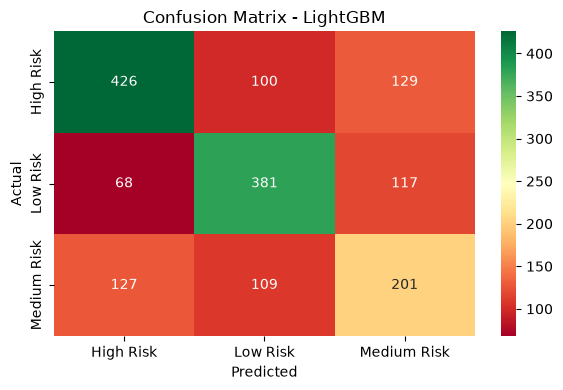


DETAILED REPORT - Random Forest
              precision    recall  f1-score   support

   High Risk       0.68      0.68      0.68       655
    Low Risk       0.64      0.68      0.66       566
 Medium Risk       0.46      0.41      0.43       437

    accuracy                           0.61      1658
   macro avg       0.59      0.59      0.59      1658
weighted avg       0.61      0.61      0.61      1658



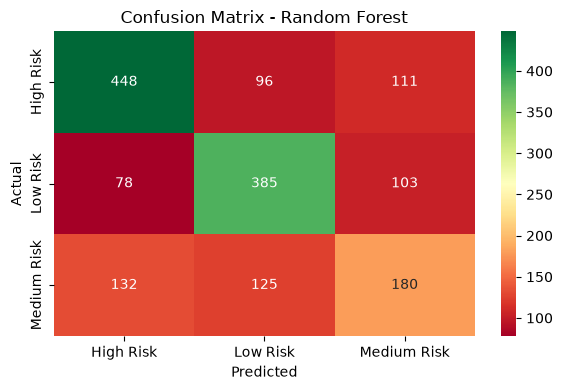

In [15]:
# Cell 5 - Detailed report for top 2 models
for name in ['LightGBM', 'Random Forest']:
    model = models[name]
    y_pred = model.predict(X_test)
    
    print(f"{'='*50}")
    print(f"DETAILED REPORT - {name}")
    print(f"{'='*50}")
    print(classification_report(
        y_test, y_pred, 
        target_names=le_target.classes_
    ))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', 
                xticklabels=le_target.classes_,
                yticklabels=le_target.classes_,
                cmap='RdYlGn')
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    print()